In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jice.util import load_region_yamls, log_episode_stats_to_wandb
from jice.algorithms import *
from jice.environment import Rice, OptimalMitigation, BasicClub
import matplotlib.pyplot as plt 

seed = 0
seed = jax.random.PRNGKey(seed)
num_regions = 3 # 3, 7, 20
env = Rice(
    region_params=load_region_yamls(num_regions),
    num_regions=num_regions,
    negotiation_on=True,
    # Set any options...

    train_env=False # Leave at False to get the state per timestep in the info dict
)

def step_full_timestep(state, actions, timestep):
    """
        Perform a full timestep of the environment, including all negotiation stages.
    """
    # Here we do not create new actions for each stage, but a real agent would do this.
    for stage in range(env.STEP_STAGES):
        stage = (stage + 1) % env.STEP_STAGES
        (obs, reward, done, discount, info), state = env.step(seed, state, actions[timestep], negotiation_stage=stage)
    timestep += 1
    return state, timestep, (obs, reward, done, discount, info)


/home/koen-xps/Downloads/miniconda/envs/ricejax/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


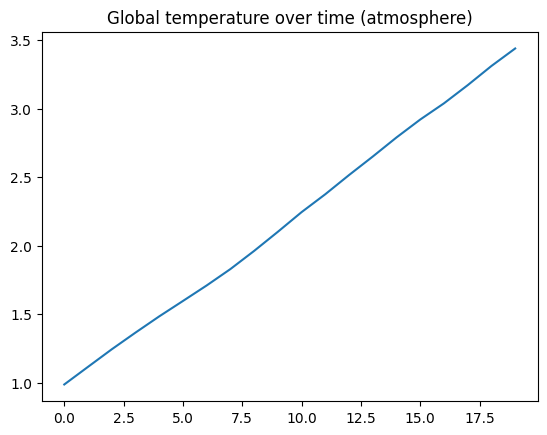

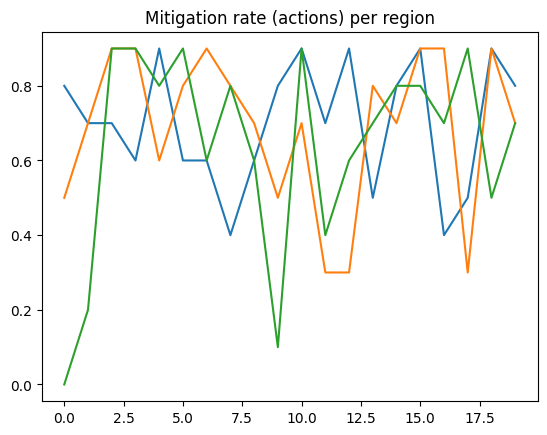

In [2]:
"""
    Effectively, we can just create action arrays per timestep and pass them to the step function.
    The dict at each timestep will contain the state of the environment at that timestep.
"""

# E.g. random actions:
random_actions = jax.random.randint(
    seed, 
    shape=(20, env.num_regions, len(env.action_nvec)), 
    minval=0, 
    maxval=env.num_discrete_action_levels
)

obs, state = env.reset(key=seed)
timestep = 0

# Checking temps and mitigation rates
temps, mitigation_rates = [], []
for i in range(20):
    state, timestep, (obs, reward, done, discount, info) = step_full_timestep(state, random_actions, timestep)
    temps.append(info['global_temperature']['atmosphere'])
    mitigation_rates.append(info['mitigation_rates_all_regions'])

plt.plot(temps)
plt.title("Global temperature over time (atmosphere)")
plt.show()
for i in range(num_regions):
    plt.plot([x[i] for x in mitigation_rates])
plt.title("Mitigation rate (actions) per region")
plt.show()